In [25]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## Task 1

In [9]:
class GroceryManager:
    def __init__(self):
        self.items: dict[str, tuple[int, float]] = {}
    
    def add_item(self, item, quantity, price):
        self.items[item] = (quantity, price)
    
    def remove_item(self, item):
        if item not in self.items:
            print("Item not in the list")
            return
        self.items.pop(item, None)

    def view_list(self):
        print(self.items)
    
    def calculate_total(self):
        total = 0.0
        for _, (quantity, price) in self.items.items():
            total += quantity * price
        
        print(f"Total is {total}")
    

## Task 2

In [10]:
students = {
    "1": {
        "Name": "Muhammed Owais",
        "Major": "Artificial Intelligence",
        "Grades": [4, 4, 3, 2]
    },
    "2": {
        "Name": "Ayesha Khan",
        "Major": "Artificial Intelligence",
        "Grades": [4, 3, 4, 4]
    },
    "3": {
        "Name": "Ali Raza",
        "Major": "Computer Science",
        "Grades": [3, 4, 3, 2]
    },
    "4": {
        "Name": "Sara Ahmed",
        "Major": "Software Engineering",
        "Grades": [4, 3, 4, 3]
    },
    "5": {
        "Name": "Hamza Malik",
        "Major": "Data Science",
        "Grades": [3, 2, 4, 3]
    }
}

def find_top_student():
    top_student_name = ""
    top_student_avg = 0.0
    for id, info in students.items():
        name, major, grades = info.values()
        avg = sum(grades) / len(grades)
        if avg > top_student_avg:
            top_student_avg = avg
            top_student_name = name
    print(f"Top Student is: {top_student_name}")

def find_major_students(major):
    for id, info in students.items():
        name, std_major, grades = info.values()
        if major == std_major:
            print(name)
        

## Task 3

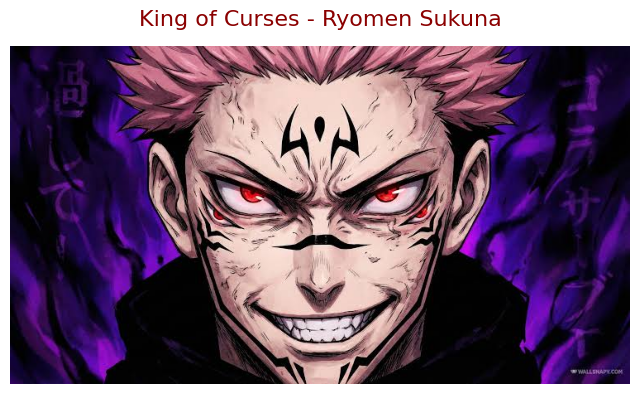

In [11]:
image_path = "sukuna.jpg"
image = cv2.imread(image_path)

if image is None:
    print("Error: Image not found")
else:
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(8, 6))
    plt.axis("off")

    plt.title("King of Curses - Ryomen Sukuna", fontsize= 16, color='darkred', pad=15)

    plt.imshow(image_rgb)
    plt.show()

## Task 4

Exact center coordinates: (400, 400)


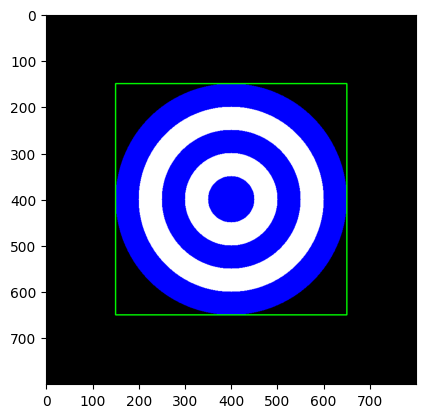

In [12]:
canvas = np.zeros((800, 800, 3), dtype=np.uint8)

center_x = 800 // 2
center_y = 800 // 2
print(f"Exact center coordinates: ({center_x}, {center_y})")

radii = [250, 200, 150, 100, 50]
colors = [
    (0, 0, 255),    # Red (BGR format)
    (255, 255, 255), # White
    (0, 0, 255),    # Red
    (255, 255, 255), # White
    (0, 0, 255)     # Red
]

for radius, color in zip(radii, colors):
    # -1 thickness fills the circle completely
    cv2.circle(canvas, (center_x, center_y), radius, color, thickness=-1)

outermost_radius = radii[0]
top_left = (center_x - outermost_radius, center_y - outermost_radius)
bottom_right = (center_x + outermost_radius, center_y + outermost_radius)

cv2.rectangle(canvas, top_left, bottom_right, (0, 255, 0), thickness=2)

plt.imshow(canvas)
plt.show()

## Task 5

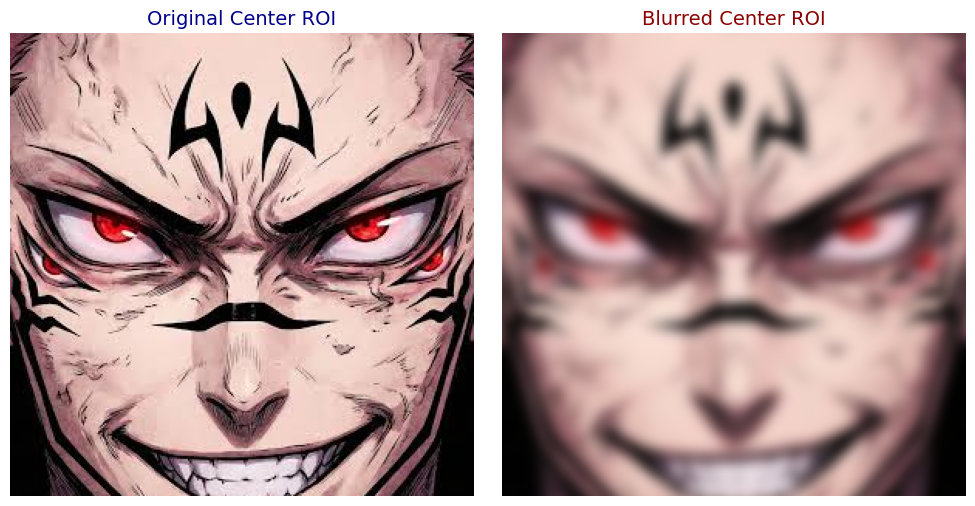

In [13]:
img_blurred = cv2.GaussianBlur(image_rgb, (25, 25), 0)

height, width, _ = image_rgb.shape
center_x = width // 2
center_y = height // 2

y_start, y_end = center_y - 150, center_y + 150
x_start, x_end = center_x - 150, center_x + 150

roi_original = image_rgb[y_start:y_end, x_start:x_end]
roi_blurred = img_blurred[y_start:y_end, x_start:x_end]

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Plot Original ROI
axes[0].imshow(roi_original)
axes[0].axis("off")  # Turn off axes
axes[0].set_title(
    "Original Center ROI", fontsize=14, color="darkblue"
)  # Custom title parameters

# Plot Blurred ROI
axes[1].imshow(roi_blurred)
axes[1].axis("off")  # Turn off axes
axes[1].set_title(
    "Blurred Center ROI", fontsize=14, color="darkred"
)  # Custom title parameters

# Render the plots neatly
plt.tight_layout()
plt.show()

## Task 6

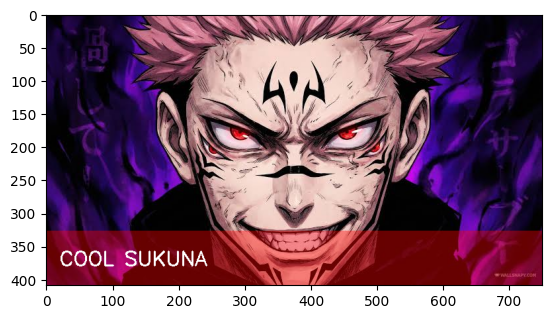

In [16]:
height, width, channels = image_rgb.shape

y_start = int(height * 0.80)
overlay = image_rgb.copy()

cv2.rectangle(overlay, (0, y_start), (width, height), (255, 0, 0), thickness=-1)

alpha = 0.6
beta = 0.4
blended_img = cv2.addWeighted(image_rgb, alpha, overlay, beta, 0)

text = "COOL SUKUNA"
font = cv2.FONT_HERSHEY_SIMPLEX
font_scale = 1.0
text_color = (255, 255, 255)  # White text
thickness = 2

# Dynamically calculate text size to center it vertically within the 20% box region
(text_width, text_height), baseline = cv2.getTextSize(
    text, font, font_scale, thickness
)
box_height = height - y_start
text_x = 20  # Left padding from the image margin
text_y = y_start + (box_height + text_height) // 2

# Write text onto the blended image result
cv2.putText(blended_img, text, (text_x, text_y), font, font_scale, text_color, thickness)

# 5. Display the stylized result on screen
plt.imshow(blended_img)
plt.show()

## Task 7

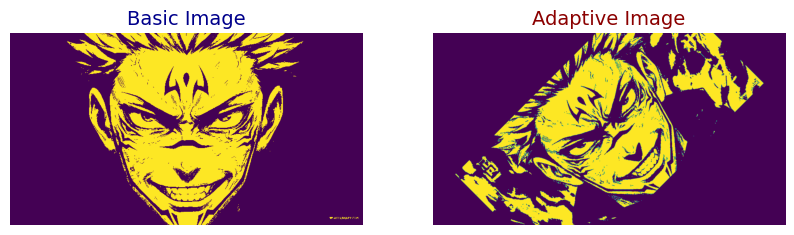

In [22]:
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

ret_basic, basic_image = cv2.threshold(gray_image, 100, 200, cv2.THRESH_BINARY)
adap_image = cv2.adaptiveThreshold(
    gray_image,
    255,
    cv2.ADAPTIVE_THRESH_MEAN_C,
    cv2.THRESH_BINARY,
    199,  # Block size (odd number)
    5,    # Constant C subtracted from the mean
)

height, width = adap_image.shape[:2]
center = (width / 2, height / 2)

rotation_matrix = cv2.getRotationMatrix2D(center, 45, 0.8)
adap_image_rotated = cv2.warpAffine(adap_image, rotation_matrix, (width, height))

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(basic_image)
axes[0].axis("off")  # Turn off axes
axes[0].set_title(
    "Basic Image", fontsize=14, color="darkblue"
) 

axes[1].imshow(adap_image_rotated)
axes[1].axis("off")  # Turn off axes
axes[1].set_title(
    "Adaptive Image", fontsize=14, color="darkred"
)
plt.show()

## Task 8

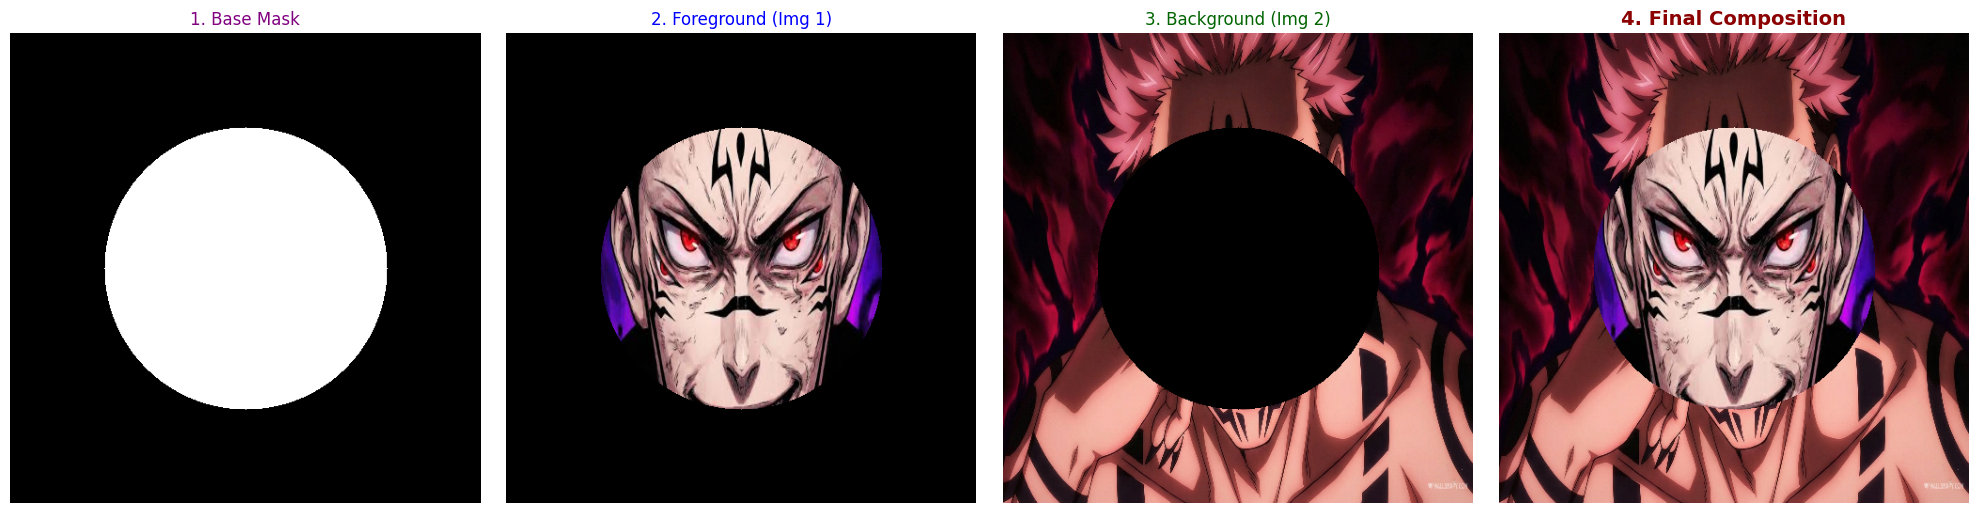

In [24]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# 1. Load and resize images to 500x500
img1 = cv2.imread("sukuna.jpg")
img2 = cv2.imread("sukuna_2.jpg")

if img1 is None or img2 is None:
    raise FileNotFoundError(
        "Error: One or both images could not be loaded. Check paths!"
    )

img1_resized = cv2.resize(img1, (500, 500))
img2_resized = cv2.resize(img2, (500, 500))

# 2. Create the binary mask (500x500 black canvas)
mask = np.zeros((500, 500), dtype=np.uint8)
cv2.circle(mask, (250, 250), 150, 255, thickness=-1)

# 3. Perform the bitwise operations
foreground = cv2.bitwise_and(img1_resized, img1_resized, mask=mask)
mask_inverted = cv2.bitwise_not(mask)
background = cv2.bitwise_and(img2_resized, img2_resized, mask=mask_inverted)
combined_result = cv2.bitwise_or(foreground, background)

fg_rgb = cv2.cvtColor(foreground, cv2.COLOR_BGR2RGB)
bg_rgb = cv2.cvtColor(background, cv2.COLOR_BGR2RGB)
final_rgb = cv2.cvtColor(combined_result, cv2.COLOR_BGR2RGB)
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# Plot 1: The Mask (Use cmap="gray" since it's a 1-channel binary image)
axes[0].imshow(mask, cmap="gray")
axes[0].set_title("1. Base Mask", fontsize=12, color="purple")
axes[0].axis("off")

# Plot 2: Foreground Cutout
axes[1].imshow(fg_rgb)
axes[1].set_title("2. Foreground (Img 1)", fontsize=12, color="blue")
axes[1].axis("off")

# Plot 3: Background Cutout
axes[2].imshow(bg_rgb)
axes[2].set_title("3. Background (Img 2)", fontsize=12, color="darkgreen")
axes[2].axis("off")

# Plot 4: Final Merged Result
axes[3].imshow(final_rgb)
axes[3].set_title("4. Final Composition", fontsize=14, color="darkred", fontweight="bold")
axes[3].axis("off")

# Render all the subplots cleanly without overlapping headers
plt.tight_layout()
plt.show()

## Task 9

In [26]:
# OpenCV loads images in BGR order. Split them into individual color matrices.
b_channel, g_channel, r_channel = cv2.split(image)

# Flatten each 2D pixel array into a 1D array using .flatten() or .ravel()
b_flat = b_channel.flatten()
g_flat = g_channel.flatten()
r_flat = r_channel.flatten()

# 2. Load these three 1D arrays into a Pandas DataFrame with the specific column order
df = pd.DataFrame({"Red": r_flat, "Green": g_flat, "Blue": b_flat})

summary_stats = df.describe()

# Print the final DataFrame summary metrics to your console terminal
print("--- Color Channel Statistical Summary ---")
print(summary_stats)


--- Color Channel Statistical Summary ---
                 Red          Green           Blue
count  306750.000000  306750.000000  306750.000000
mean       89.514360      60.866047      86.932932
std        88.988052      77.562333      70.819295
min         0.000000       0.000000       0.000000
25%        11.000000       3.000000      19.000000
50%        49.000000      11.000000      74.000000
75%       176.000000     121.000000     148.000000
max       255.000000     255.000000     254.000000
